# Часть 1. Проверка гипотезы в Python и составление аналитической записки

## Введение

- Автор: Стогниева Дарья Александровна
- Дата: 09.04.2026

## Цели и задачи проекта

**Цель проекта:** Проверить, проводят ли пользователи из Санкт-Петербурга в среднем больше времени в приложении, чем пользователи из Москвы, и доказать это статистически.

**Задачи проекта:**

1. Загрузить подготовленные данные из файла в Python

2. Проверить данные на наличие дубликатов

3. Разделить пользователей на 2 группы
    
4. Провести разведочный анализ
    
5. Проверить статистическую гипотезу с помощью t-теста

6. Подготовить аналитическую записку

## Описание данных

Данные из файла yandex_knigi_data.csv содержат следующие поля:

* `city` — город пользователя;
* `puid` — идентификатор пользователя;
* `hours` — общее количество часов активности.

## Содержимое проекта

**Основные шаги проекта:**

1. Загрузка данных и знакомство с ними
2. Проверка гипотезы в Python
3. Аналитическая записка

## 1. Загрузка данных и знакомство с ними

In [1]:
# Импортируем необходимые библиотеки для дальнейшей работы
import pandas as pd
from scipy import stats as st
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Загрузим данные из файла 
df_knigi = pd.read_csv('/datasets/yandex_knigi_data.csv')

In [3]:
# Выведем первые строки полученного датафрейма
df_knigi.head(5)

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [4]:
# Удалим лишний столбец ('Unnamed: 0')
df_knigi = df_knigi.drop(columns=['Unnamed: 0'])

In [5]:
# Выведем информацию о датасете с помощью метода info()
df_knigi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 206.0+ KB


Данные в столбце `puid` лучше будет привести к типу object.

In [6]:
df_knigi['puid'] = df_knigi['puid'].astype('object')

Теперь, перейдем к поиску и обработке дубликатов по полю с идентификаторами пользователей.

In [7]:
# Проверяем наличие дубликатов по полю 'puid'
df_knigi['puid'].duplicated().sum()

244

In [8]:
# Удалим найденые дубликаты
df_knigi = df_knigi.drop_duplicates(subset='puid')

In [9]:
# Для дальнейшего анализа разделим пользователей на группы по городам
moscow = df_knigi[df_knigi['city'] == 'Москва']
spb = df_knigi[df_knigi['city'] == 'Санкт-Петербург']

С помощью метода describe() посчитаем описательные статистики для каждой из групп и сравним их.

In [10]:
# Описательная статистика для группы из Москвы
moscow.describe()

,hours
count,6234.000000
mean,10.881092
std,36.851683
min,0.000018
25%,0.059903
50%,0.924498
75%,5.939972
max,857.209373


In [11]:
# Описательная статистика для группы из Санкт-Петербурга
spb.describe()

,hours
count,2306.000000
mean,11.264433
std,39.831755
min,0.000025
25%,0.060173
50%,0.875355
75%,6.138424
max,978.764775


Количество пользователей из Москвы значительно превышает количество пользователей из Санкт-Петербурга (6234 против 2306, примерно в 2.7 раза больше).

Несмотря на различие в размерах выборок, основные описательные статистики в группах близки:
средние значения (10.88 в Москве и 11.26 в Санкт-Петербурге), медианы (0.92 и 0.87) и стандартные отклонения (36.85 и 39.83) отличаются незначительно.

При этом наблюдается существенная разница между средним и медианой в обеих группах, что указывает на сильную асимметрию распределения и наличие выбросов (пользователей с очень большим временем активности).

Построим диаграммы размаха для каждой из групп, чтобы проверить выбросы.

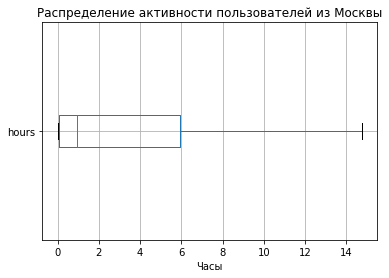

In [12]:
# Строим диаграмму размаха для группы из Москвы с помощью метода boxplot()
boxplot = moscow.boxplot(column='hours',
                     vert=False,
                     showfliers=False,
                     figsize=(6, 4))

# Добавляем заголовок и метку оси X
boxplot.set_title('Распределение активности пользователей из Москвы')
boxplot.set_xlabel('Часы')

# Выводим график
plt.show() 

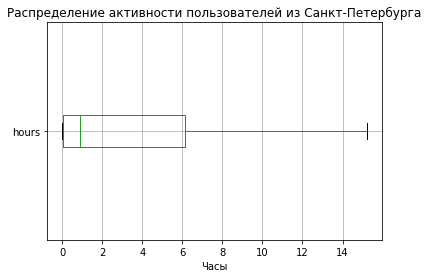

In [13]:
# Строим диаграмму размаха для группы из Санкт-Петербурга с помощью метода boxplot()
boxplot = spb.boxplot(column='hours',
                     vert=False,
                     showfliers=False,
                     figsize=(6, 4))

# Добавляем заголовок и метку оси X
boxplot.set_title('Распределение активности пользователей из Санкт-Петербурга')
boxplot.set_xlabel('Часы')

# Выводим график
plt.show() 

Диаграмма размаха не выявила выбросов, однако анализ описательных статистик показывает значительную разницу между средним и медианой, а также наличие экстремально больших значений. Это свидетельствует о сильной асимметрии распределения и наличии длинного правого хвоста.

Несмотря на это, с учётом большого размера выборок, для проверки гипотезы может быть применён t-тест благодаря центральной предельной теореме.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуем статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

Для проверки гипотез будем использовать t-тест для независимых выборок. Мы проверяем одностроннюю альтернативную гипотезу. Уровень статистической значимости будет равен 0.05.

In [14]:
# Обзначаем уровень статистической значимости
alpha = 0.05 

results = st.ttest_ind(
    moscow['hours'], 
    spb['hours'],
    alternative='less')

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 0.338193679651558
Не получилось отвергнуть нулевую гипотезу


## 3. Аналитическая записка
Для проверки гипотезы был использован t-тест для независимых выборок. Уровень статистической значимости принят равным 0.05.

Полученное значение p-value: 0.338193679651558. На основе полученного p-value, можно сделать вывод, что недостаточно оснований отвергнуть нулевую гипотезу.

Возможные причины, объясняющие полученные результаты:

* Поведение пользователей в Москве и Санкт-Петербурге может быть схожим.
* Меньший размер выборки пользователей из Санкт-Петербурга по сравнению с Москвой.
* Высокая вариативность времени активности пользователей

----

# Часть 2. Анализ результатов A/B-тестирования

## Введение

**Цель исследования:**

Оценить корректность проведения A/B-теста и определить, приводит ли новый упрощённый интерфейс интернет-магазина к статистически значимому увеличению конверсии пользователей в покупателей в течение 7 дней после регистрации.

**Задачи исследования:**

1. Загрузить и предобработать данные
2. Проверить корректность проведения A/B-теста
3. Сформировать метрики
4. Проанализировать результаты теста
5. Сформулировать выводы и рекомендации

## Описание данных

1. `/ab_test_participants.csv` — таблица участников тестов.

Структура файла:
* `user_id` — идентификатор пользователя;
* `group` — группа пользователя;
* `ab_test` — название теста;
* `device` — устройство, с которого происходила регистрация.

2. `/ab_test_events.zip` — архив с одним csv-файлом, в котором собраны события 2020 года.

Структура файла:
* `user_id` — идентификатор пользователя;
* `event_dt` — дата и время события;
* `event_name` — тип события;
* `details` — дополнительные данные о событии.

## Содержимое проекта

**Основные шаги проекта:**

1. Загрузка данных, оценка их целостности
2. Проверка корректности проведения A/B-теста

    2.1 Проверка распределения пользователей

    2.2 Проверка соответствия тесту и временных рамок

    2.3 Проверка достаточности выборки


3. Оценка результатов A/B-тестирования

    3.1 Расчёт конверсии

    3.2 Статистическая проверка гипотезы


4. Выводы и рекомендации

## 1. Загрузка данных, оценка их целостности.

In [15]:
# Загружаем данные из файлов
# Сохраним их в переменные 'participants' и 'events'
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [16]:
participants.head(5)

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [17]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [18]:
events.head(5)

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [19]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


Данные в обоих датафреймах хранятся в верных типых данных и, на первый взгляд, соответствуют своему описанию. Пропуски есть только в столбце `details` датафрейма `events`, но так как он хранит дополнительную информацию о событии, обрабатывать эти пропуски мы не будем.

Проверим датафреймы на наличие дубликатов.

In [20]:
# Проверяем дубликаты в датафрейме participants
participants.duplicated().sum()

0

In [21]:
# Проверим дублирующиеся значение user_id
participants['user_id'].duplicated().sum()

887

887 повторяющихся пользователей. Вероятно, это связано с тем, что пользователь мог учавствовать и в других тестах. Проверим, сколько пользователей, учавствовали в более чем одном тесте.

In [22]:
# Считаем пользователей, которые учавствовали в двух и более тестах
participants.groupby('user_id')['ab_test'].nunique().value_counts()

1    12751
2      887
Name: ab_test, dtype: int64

887 пользователей учавствовали в двух тестах. Исключим их из анализа, так как не известно какой именно тест повлиял на их действия.

In [23]:
# Считаем количество тестоа для каждого пользователя
users_multiple_tests = participants.groupby('user_id')['ab_test'].nunique()

# Сохраняем пользователей, которые учавствовали в более чем одном тесте
users_multiple_tests = users_multiple_tests[users_multiple_tests > 1].index

# Удаляем их из датафрейма
participants = participants[~participants['user_id'].isin(users_multiple_tests)]

In [24]:
# Проверяем дубликаты в датафрейме events
events.duplicated().sum()

36318

Датафрейм `events` содержит 36318 полных дубликатов, которые необходимо удалить, потому что они не несут новой информации и искажают подсчёт событий.

In [25]:
# Удаляем полные дубликаты из events
events = events.drop_duplicates().reset_index(drop=True)

In [26]:
events.head(5)

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


## 2. Проверка корректности проведения A/B-теста

### 2.1. Проверка распределения пользователей

Для начала, отберем всех пользователей только из нужного нам теста (interface_eu_test).

In [27]:
participants = participants[participants['ab_test'] == 'interface_eu_test']

Теперь, проверим баланс групп.

In [28]:
# Сгруппируем данные по тестовым группам и рассчитаем количество уникальных пользователей для каждой из них
unique_users = participants.groupby('group')['user_id'].nunique()

# Выведем результат
unique_users

group
A    4952
B    5011
Name: user_id, dtype: int64

Судя по полученным данным, в группе B на 59 пользователей больше, чем в группе A. Разница небольшая, так что мы можем ее проигнорировать.

Теперь, убедимся, что никто из пользователей случайно не попал в обе группы одновременно.

In [29]:
# Выбираем пользователей для групп А и В
group_a = participants[participants['group'] == 'A']['user_id']
group_b = participants[participants['group'] == 'B']['user_id']

# Ищем, есть ли пересечения
intersection = list(set(group_a) & set(group_b))

# Выводим результат
intersection

[]

Пользователей, которые, были бы одновременно в группе А и В, нет.

Полезно также убедиться в том, что пользователи равномерно распределены по типам устройств.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B

In [30]:
# Найдем доли каждого типа устройства для пользователей из группы А
device_share_a = participants[participants['group'] == 'A'].groupby('device')['user_id'].nunique() / participants[participants['group'] == 'A']['user_id'].nunique()


# Найдем доли каждого типа устройства для пользователей из группы B
device_share_b = participants[participants['group'] == 'B'].groupby('device')['user_id'].nunique() / participants[participants['group'] == 'B']['user_id'].nunique()

print(f"Доля каждого типа устройства для пользователей из группы A")
display(device_share_a)
print(f"Доля каждого типа устройства для пользователей из группы B")
display(device_share_b)

Доля каждого типа устройства для пользователей из группы A


device
Android    0.457189
Mac        0.103998
PC         0.246971
iPhone     0.191842
Name: user_id, dtype: float64

Доля каждого типа устройства для пользователей из группы B


device
Android    0.442626
Mac        0.101976
PC         0.259828
iPhone     0.195570
Name: user_id, dtype: float64

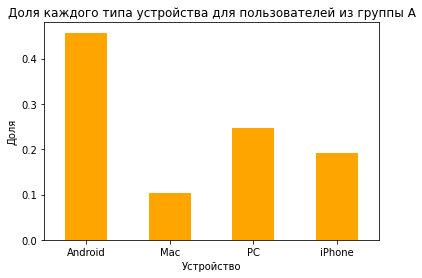

In [31]:
# Строим столбчатую диаграмму для группы А
device_share_a.plot(kind='bar',color='orange')

# Добавим заголовок и подписи осей
plt.title('Доля каждого типа устройства для пользователей из группы A')
plt.xlabel('Устройство')
plt.ylabel('Доля')

# Уберем поворот надписей по оси Х
plt.xticks(rotation=0)

# Покажем диаграмму
plt.show()

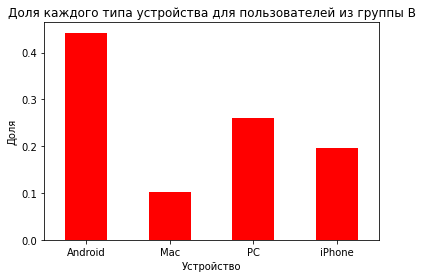

In [32]:
# Строим столбчатую диаграмму для группы B
device_share_b.plot(kind='bar',color='red')

# Добавим заголовок и подписи осей
plt.title('Доля каждого типа устройства для пользователей из группы B')
plt.xlabel('Устройство')
plt.ylabel('Доля')

# Уберем поворот надписей по оси Х
plt.xticks(rotation=0)

# Покажем диаграмму
plt.show()

По полученным диаграммам, можно сделать вывод, что распределение пользователей по типам устройств в группах A и B в целом совпадает. Доли устройств отличаются незначительно: в группе A немного выше доля Android и Mac, а в группе B - iPhone и PC. Эти различия невелики и, скорее всего, не оказывают существенного влияния на результаты A/B-теста, что говорит о корректном разделении пользователей на группы.

### 2.2. Проверка соответствия тесту и временных рамок

Необходимо отфильтровать события в `events` и оставить только события, связанные с участвующими в изучаемом тесте пользователями.

In [33]:
events = events[events['user_id'].isin(participants['user_id'])]

Определим горизонт анализа: рассчитаем время совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации.

In [34]:
# Определяем регистрацию по полю event_name
registration_events = events[events['event_name'] == 'registration']

In [35]:
# Создаем новый столбец с датой регистрации пользователя
participants = participants.merge(registration_events[['user_id', 'event_dt']],on='user_id',how='left')

# Переименуем для удобства
participants = participants.rename(columns={'event_dt': 'reg_dt'})

# Выведем результат
participants.head()

,user_id,group,ab_test,device,reg_dt
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31
1,001E72F50D1C48FA,A,interface_eu_test,Mac,2020-12-17 15:44:05
2,002412F1EB3F6E38,B,interface_eu_test,Mac,2020-12-09 09:36:50
3,002540BE89C930FB,B,interface_eu_test,Android,2020-12-08 18:06:07
4,0031F1B5E9FBF708,A,interface_eu_test,Android,2020-12-14 00:47:10


In [36]:
# Проверим, есть ли пропуски в новом столбце с датой регистрации
participants.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9963 entries, 0 to 9962
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   user_id  9963 non-null   object        
 1   group    9963 non-null   object        
 2   ab_test  9963 non-null   object        
 3   device   9963 non-null   object        
 4   reg_dt   9963 non-null   datetime64[ns]
dtypes: datetime64[ns](1), object(4)
memory usage: 467.0+ KB


Пропусков нет, а значит все данные корректны и мы знаем даты  регистраций всех пользователей.

In [37]:
# Объединяем события с регистрацией, чтобы знать, когда зарегистрировался каждый пользователь:
events = events.merge(participants[['user_id', 'reg_dt', 'group']], on = 'user_id', how = 'left')

In [38]:
# Фильтруем события по времени
events = events[(events['event_dt'] >= events['reg_dt']) & (events['event_dt'] <= events['reg_dt'] + pd.Timedelta(days=7))]

In [39]:
# Убедимся, что нет событий до регистрации:
print(events[events['event_dt'] < events['reg_dt']].shape[0])

0


In [40]:
# Проверим, что нет событий после 7 дней:
(events['event_dt'] > events['reg_dt'] + pd.Timedelta(days=7)).sum()

0

Данные содержат только те события, которые были выполнены в течение первых семи дней с момента регистрации.

### 2.3. Проверка достаточности выборки

После фильтраций, необходимо оценить достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [41]:
# Зададим параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
mde = 0.03 # Минимальный детектируемый эффект
p1 = 0.3 # Базовый показатель конверсии
p2 = p1 + mde # +3 процентных пункта
effect_size = proportion_effectsize(p1, p2)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


In [42]:
# Еще раз выведем размеры каждой группы
participants['group'].value_counts()

B    5011
A    4952
Name: group, dtype: int64

Фактический размер(4952 и 5011) групп больше расчётного (3761). Следовательно, тест достаточно мощный чтобы показать статистически значимые результаты.

## 3. Оценка результатов A/B-тестирования

### 3.1. Расчет конверсии

Рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [43]:
# Для каждой группы считаем количество посетителей, сделавших покупку
paying_users = events[events['event_name'] == 'purchase'].groupby('group')['user_id'].nunique()

# Для каждой группы считаем общее количество посетителей
users_count =  participants.groupby('group')['user_id'].nunique()

# Выводим результат
print(f'Количество посетителей, сделавших покупку, для каждой группы:')
display(paying_users)
print(f'Общее количество посетителей для каждой группы:')
display(users_count)

Количество посетителей, сделавших покупку, для каждой группы:


group
A    1377
B    1480
Name: user_id, dtype: int64

Общее количество посетителей для каждой группы:


group
A    4952
B    5011
Name: user_id, dtype: int64

In [44]:
# Посчитаем процентное соотношение посетителей, сделавших покупку к общему числу посетителей, в каждой группе
conversion = (paying_users / users_count * 100).round(2)

# Выведем результат
for group, value in conversion.items():
    print(f'Процент посетителей, сделавших покупку для группы {group}: {value:.2f}%')

Процент посетителей, сделавших покупку для группы A: 27.81%
Процент посетителей, сделавших покупку для группы B: 29.54%


In [45]:
# Считаем относительный прирост
relative_growth = (conversion['B'] - conversion['A']) / conversion['A']

# Считаем абсолютный прирост
absolute_growth = (conversion['B'] - conversion['A'])

print(f'Относительный прирост конверсии: {relative_growth:.2f}%')
print(f'Абсолютный прирост конверсии: {absolute_growth:.2f} п.п.')

Относительный прирост конверсии: 0.06%
Абсолютный прирост конверсии: 1.73 п.п.


Абсолютный прирост конверсии составил +1.73 п.п., что ниже целевого значения в 3 п.п.Относительный прирост составил +0.06%, что указывает на положительный эффект нового интерфейса, однако он не достигает заданного порога.

### 3.2. Статистическая проверка гипотезы

Сформулируем нулевую и альтернативные гипотезы: 
* **Нулевая гипотеза:** Изменение интерфейса никак не повлияло на увеличение коверсии в покупку пользователями.
* **Альтернативная гипотеза:** Конверсия в покупку, у пользователей, которые видели новый интерфейс онлайн-магазина, выше, чем у пользователей, которые видели старую версию.

Для проверки изменения конверсии будем использовать статистический Z-тест пропорций.

In [46]:
# Задаем размеры групп А и В
n_a = participants[participants['group']== 'A'].shape[0]
n_b = participants[participants['group']== 'B'].shape[0]

# Задаем количество усехов для групп А и В
m_a = events[(events['event_name'] == 'purchase')&(events['group'] == 'A')]['user_id'].nunique()
m_b = events[(events['event_name'] == 'purchase')&(events['group'] == 'B')]['user_id'].nunique()

# Задаем уровень значимости, на котором проверяем гипотезу о равенстве вероятностей
alpha = 0.05

# Проводим Z-тест пропорций
stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller'
)

p_value_ztest

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения!')

pvalue=0.028262547212292124 < 0.05
Нулевая гипотеза не находит подтверждения!


## 4. Выводы и рекомендации

По проведенной оценке результатов A/B-тестирования, можно сделать вывод, что значение конверсии в тестовой группе В выше, чем в контрольной группе А. Конверсия в покупку в группе В выше на 1.73 п.п. (или на 0.06%) относительно группы А. При проверке гипотез, были использованы следующие параметры: 
* Уровень значимости = 5%.
* Мощность теста = 80%.
* Фактический размер выборки: группа A = 4952, группа B = 5011.
* Количество успехов: группа A = 1377, группа B = 1480.

При полученном значении pvalue = 0.028, нулевая гипотеза о равенстве конверсий была отвергнута, т.е. новый интерфейс статистически значимо улучшает конверсию. Однако ожидаемый эффект (увеличение конверсии на 3 п.п. и более) не достигнут. Поэтому можно рассмотреть:
* дополнительное улучшение интерфейса.
* другие элементы для усиления эффекта.